## Image Transformation 

(1073, 1800, 3)

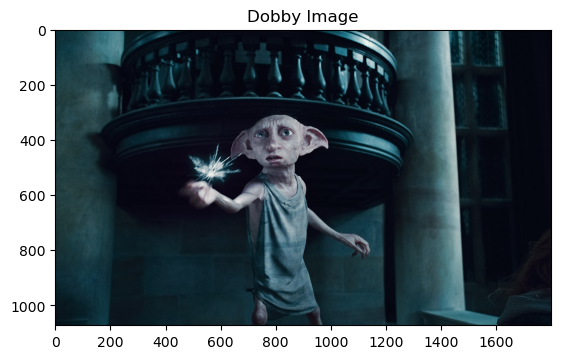

In [2]:
import cv2
import matplotlib.pyplot as plt 
import numpy as np

dobby_img = cv2.imread('dobby.jpeg')

def show_img(img,title):
    plt.title(title)
    plt.imshow(img)

img = cv2.cvtColor(dobby_img,cv2.COLOR_BGR2RGB)
show_img(img,'Dobby Image')
img.shape

# 1 .  Translation

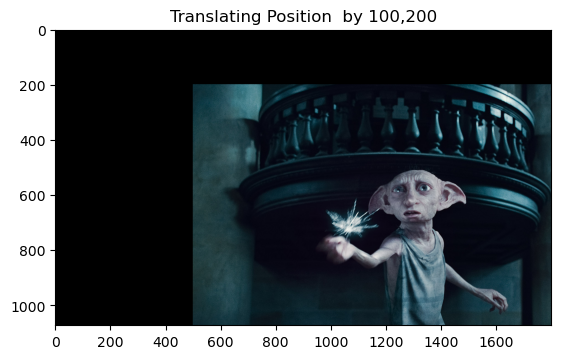

In [8]:
def translation(img,tx,ty):
    height,width = img.shape[:2]
    res = np.zeros_like(img)
    for y in range(height):
        for x in range(width):
            new_x = x + tx
            new_y = y + ty

            if 0 <= new_x < width and 0 <= new_y < height:
                res[new_y,new_x] = img[y,x]
    return res

trans= translation(img,500,200)
show_img(trans , 'Translating Position  by 100,200')

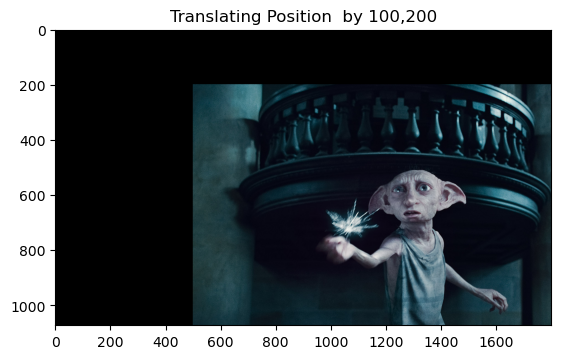

In [32]:
#by matrix : Translation
def translate_image(image, tx, ty):
    height, width = image.shape[:2]
    translation_matrix = np.array([
        [1, 0, tx],
        [0, 1, ty],
        [0, 0, 1]
    ])
    y, x = np.mgrid[0:height, 0:width]
    points = np.stack([x.ravel(), y.ravel(), np.ones_like(x.ravel())], axis=1)
    transformed_points = (translation_matrix @ points.T).T
    
    x_transformed = transformed_points[:, 0].reshape(height, width)
    y_transformed = transformed_points[:, 1].reshape(height, width)
    
    result = np.zeros_like(image)
    valid_mask = (x_transformed >= 0) & (x_transformed < width) & (y_transformed >= 0) & (y_transformed < height)
    
    x_valid = x_transformed[valid_mask].astype(int)
    y_valid = y_transformed[valid_mask].astype(int)
    
    result[y_valid, x_valid] = image[valid_mask]
    return result

trans2= translate_image(img,500,200)
show_img(trans2 , 'Translating Position  by 100,200')

    

# 2.ROTATION

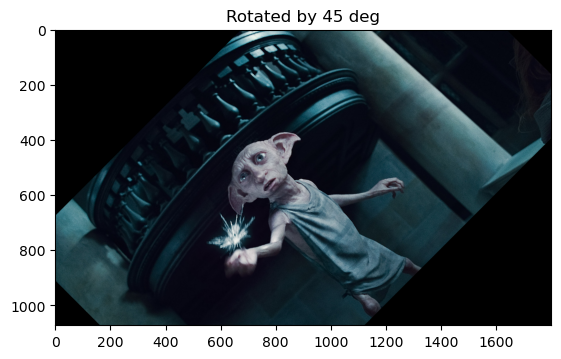

In [32]:
 

def rotation(img, deg):
    height, width = img.shape[:2]
    ang = np.radians(deg)
    cent_x, cent_y = width // 2, height // 2
    res = np.zeros_like(img)

    for new_y in range(height):
        for new_x in range(width):
            dx = new_x - cent_x
            dy = new_y - cent_y
   
            orig_x = int(dx * np.cos(ang) - dy * np.sin(ang) + cent_x)
            orig_y = int(dx * np.sin(ang) + dy * np.cos(ang) + cent_y)

            if 0 <= orig_x < width and 0 <= orig_y < height:
                res[new_y, new_x] = img[orig_y, orig_x]   

    return res


rot_img = rotation(img,45)

show_img(rot_img , 'Rotated by 45 deg')

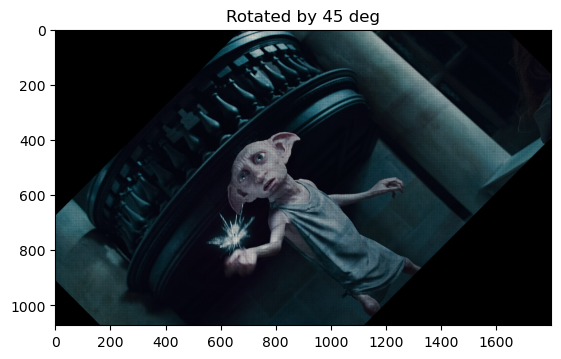

In [133]:
 

def apply_rotation(image: np.ndarray, angle: float) -> np.ndarray:
     height, width = image.shape[:2]
    
     angle_rad = np.deg2rad(-angle)
    
     rotation_matrix = np.array([
        [np.cos(angle_rad), -np.sin(angle_rad)],
        [np.sin(angle_rad), np.cos(angle_rad)]
    ])
      
     result = np.zeros_like(image)
    
     for y in range(height):
        for x in range(width):
            new_x, new_y = np.dot(rotation_matrix, np.array([x - width//2, y - height//2]))
            new_x, new_y = int(new_x + width//2), int(new_y + height//2)
            
            if 0 <= new_x < width and 0 <= new_y < height:
                result[new_y, new_x] = image[y, x]
    
     return result

rot_img2 = apply_rotation(img,45)

show_img(rot_img2 , 'Rotated by 45 deg')

# 3. Scale

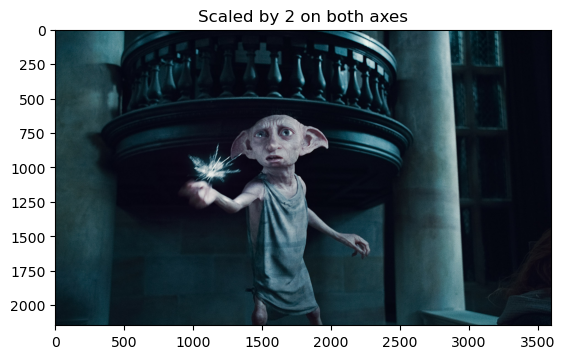

In [73]:
import numpy as np

def apply_scaling(image: np.ndarray, scale_x: float, scale_y: float) -> np.ndarray:
    height, width = image.shape[:2]
    new_height, new_width = int(height * scale_y), int(width * scale_x)

    result = np.zeros((new_height, new_width, image.shape[2]), dtype=image.dtype) if image.ndim == 3 else np.zeros((new_height, new_width), dtype=image.dtype)

    scaling_matrix = np.array([
        [scale_x, 0, 0],
        [0, scale_y, 0],
        [0, 0, 1]
    ])

    y, x = np.mgrid[0:height, 0:width]
    points = np.stack([x.ravel(), y.ravel(), np.ones_like(x.ravel())], axis=1)

    transformed_points = (scaling_matrix @ points.T).T

    x_transformed = transformed_points[:, 0].reshape(height, width)
    y_transformed = transformed_points[:, 1].reshape(height, width)

    new_x, new_y = np.meshgrid(np.arange(new_width), np.arange(new_height))
    new_x_scaled = np.clip((new_x / scale_x).astype(int), 0, width - 1)
    new_y_scaled = np.clip((new_y / scale_y).astype(int), 0, height - 1)

    result[new_y, new_x] = image[new_y_scaled, new_x_scaled]

    return result

 
scale_x = 2
scale_y = 2

scale_img =  apply_scaling(img, scale_x, scale_y)

show_img(scale_img , 'Scaled by 2 on both axes')


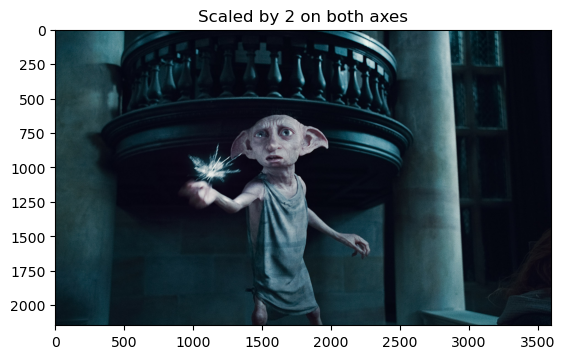

In [77]:

def apply_scaling(image: np.ndarray, scale_x: float, scale_y: float) -> np.ndarray:
    height, width = image.shape[:2]
    new_height, new_width = int(height * scale_y), int(width * scale_x)
    
    result = np.zeros((new_height, new_width, image.shape[2]), dtype=image.dtype) if image.ndim == 3 else np.zeros((new_height, new_width), dtype=image.dtype)

    new_x, new_y = np.meshgrid(np.arange(new_width), np.arange(new_height))
    orig_x = np.clip((new_x / scale_x).astype(int), 0, width - 1)
    orig_y = np.clip((new_y / scale_y).astype(int), 0, height - 1)

    result[new_y, new_x] = image[orig_y, orig_x]
    
    return result
    
scale_x = 2
scale_y = 2

scale_img2 =  apply_scaling(img, scale_x, scale_y)

show_img(scale_img2, 'Scaled by 2 on both axes')

# 4.Reflection


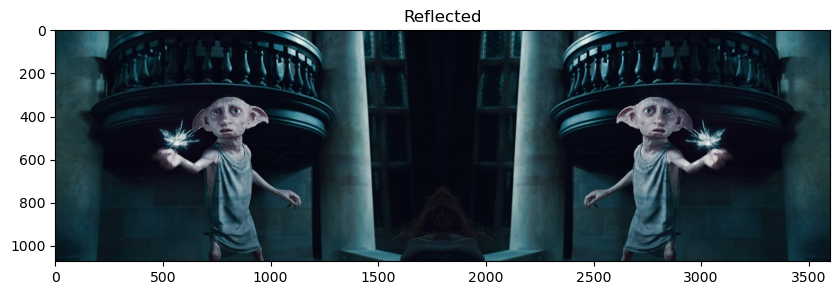

In [10]:
 #reflection

row,cl,d = img.shape
reflected_image = np.full_like(img,0)
for j in range(cl):
    reflected_image[:,j] = img[ :,cl-j-1]

new = np.hstack((img,reflected_image))
plt.figure(figsize=[10,10])
show_img(new,'Reflected')

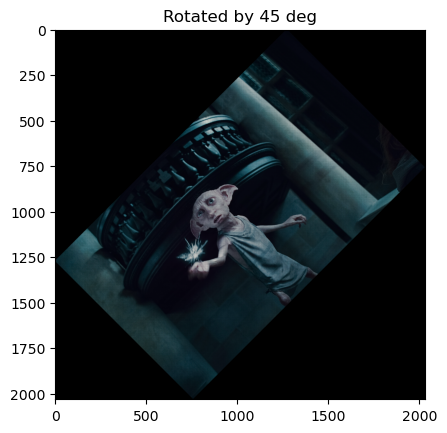

In [135]:
#ROTATION WHERE , NO IMAGE IS CUTTED

def aply_rotation(image: np.ndarray, angle: float) -> np.ndarray:
    height, width, d = image.shape
    angle_rad = np.deg2rad(-angle)
    
     rotation_matrix = np.array([
        [np.cos(angle_rad), -np.sin(angle_rad)],
        [np.sin(angle_rad), np.cos(angle_rad)]
    ])
    
     new_width = int(np.abs(width * np.cos(angle_rad)) + np.abs(height * np.sin(angle_rad)))
    new_height = int(np.abs(width * np.sin(angle_rad)) + np.abs(height * np.cos(angle_rad)))

     result = np.zeros((new_height, new_width, d), dtype=image.dtype)

     center_x, center_y = width // 2, height // 2
    new_center_x, new_center_y = new_width // 2, new_height // 2

    for y in range(height):
        for x in range(width):
             new_x, new_y = np.dot(rotation_matrix, np.array([x - center_x, y - center_y]))
            new_x, new_y = int(new_x + new_center_x), int(new_y + new_center_y)

             if 0 <= new_x < new_width and 0 <= new_y < new_height:
                result[new_y, new_x] = image[y, x]
    
    return result

rot_img3= aply_rotation(img,45)

show_img(rot_img3 , 'Rotated by 45 deg')

# 5.Image Cropping

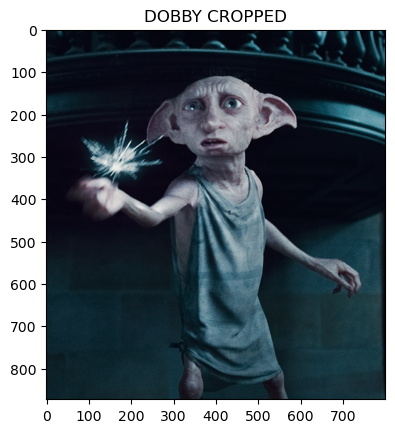

In [142]:
cropped_img = img[200:, 400:1200]
show_img(cropped_img,'DOBBY CROPPED')

# 6.Shearing

In [171]:
def shear(image, kx, ky):
    height, width, d = image.shape
    result = np.zeros_like(image)   
    
    for y in range(height):
        for x in range(width):
            new_x = int(x + kx * y)   
            new_y = int(y + ky * x)   
            
            
            if 0 <= new_x < width and 0 <= new_y < height:
                result[new_y, new_x] = image[y, x]   
                
    return result


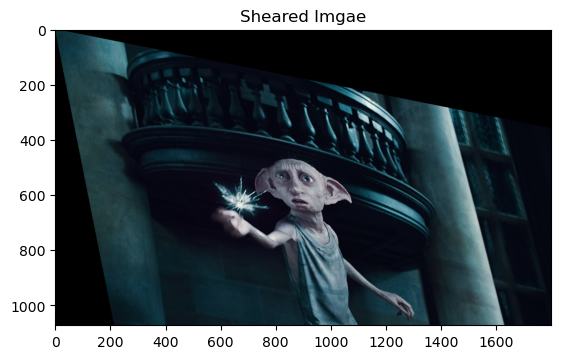

In [193]:
shear_img = shear(img,0.2,0.2)
show_img(shear_img,'Sheared Imgae')

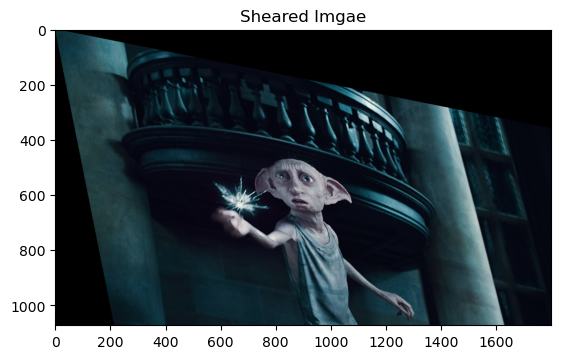

In [195]:
def shearr(image, kx, ky):
    height, width, d = image.shape
    result = np.zeros_like(image)   
    
     shear_matrix = np.array([
        [1, kx, 0],
        [ky, 1, 0],
        [0, 0, 1]
    ])
    
     for y in range(height):
        for x in range(width):
             coords = np.array([x, y, 1])
            
             new_coords = shear_matrix @ coords
            
            new_x, new_y = new_coords[0], new_coords[1]
            
             if 0 <= int(new_x) < width and 0 <= int(new_y) < height:
                result[int(new_y), int(new_x)] = image[y, x]  
                 
    return result

shear_img2 = shearr(img,0.2,0.2)
show_img(shear_img2,'Sheared Imgae')